# Coffe Quality prediction

Our Arabica coffee dataset does not have an equal split between Specialty and Below-Specialty coffee samples. Instead, it is an imbalanced dataset, we have 12% Below Specialty and 86% Specialty of coffee samples.

This problem is similar to diagnosing a disease or predicting a fraud detection. To properly approach this problem, we will make some adjustments as:
 - Handle the data splitting correctly, so we have the same ratio in the training, testing and validation sets.
 - We employ accuracy metrics that look how well the model handles the minority class, we employ precision, recall and the F1-score
 -  




In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 55

project_root = Path.cwd().parent

# Dataset

We have 1069 coffee samples with 8 selected features: variety, processing_method, moisture, defect counts, color, and altitude.
The target variable is `Total.Cup.Points`.

In [19]:
coffe_data_path = project_root / "data" / "cleaned_coffee_data.csv"

def cup_score_class(score):
    if score < 80:   
        return 0
    else: 
        return 1

    
df = pd.read_csv(coffe_data_path)
X = df.drop(columns= "Total.Cup.Points").copy()
y = df["Total.Cup.Points"].copy()
y = y.apply(cup_score_class)


print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print(y.value_counts())
print(f"\nPercentages:")
print((y.value_counts(normalize=True)*100).round(1))
X.head()


X shape: (1069, 8)
y shape: (1069,)
Total.Cup.Points
1    931
0    138
Name: count, dtype: int64

Percentages:
Total.Cup.Points
1    87.1
0    12.9
Name: proportion, dtype: float64


,Variety,Processing.Method,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,altitude_mean_meters
0,NaN,Washed / Wet,0.12,0,0.0,Green,0,2075.0
1,Other,Washed / Wet,0.12,0,0.0,Green,1,2075.0
2,Bourbon,NaN,0.00,0,0.0,NaN,0,1700.0
3,NaN,Natural / Dry,0.11,0,0.0,Green,2,2000.0
4,Other,Washed / Wet,0.12,0,0.0,Green,2,2075.0


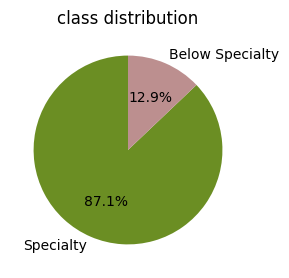

In [20]:
class_counts = y.value_counts()
plt.figure(figsize=(3, 3))
plt.pie(class_counts,labels=["Specialty", "Below Specialty",], autopct='%1.1f%%', 
    startangle=90,colors = ['olivedrab', 'rosybrown'])
plt.title("class distribution")
plt.tight_layout()
plt.show()

# Splitting the Dataset

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=RANDOM_STATE, stratify =y
)
print(f"tran sample: {X_train.shape}, test samples: {X_test.shape}")

tran sample: (855, 8), test samples: (214, 8)


We define an approach to deal with the missing values of the numerical and categorical features:

In [22]:
numerical_features = ["altitude_mean_meters", "Moisture",
                    "Category.One.Defects", "Category.Two.Defects", "Quakers"]

categorical_features = ["Variety", "Processing.Method", "Color"]

numerical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features )
])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Logistic Regression 

We start predicting the raw cup score to understand how well the non-sensory features explain the quality.

In [27]:


lr_model = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred, target_names=['Majority Class (0)', 'Minority Class (1)']))

[[ 20   8]
 [ 51 135]]
                    precision    recall  f1-score   support

Majority Class (0)       0.28      0.71      0.40        28
Minority Class (1)       0.94      0.73      0.82       186

          accuracy                           0.72       214
         macro avg       0.61      0.72      0.61       214
      weighted avg       0.86      0.72      0.77       214



# Random Forest Classifier

Random Forest classification report:
              precision    recall  f1-score   support

           0      0.286     0.667     0.400        15
           1      0.972     0.874     0.921       199

    accuracy                          0.860       214
   macro avg      0.629     0.771     0.660       214
weighted avg      0.924     0.860     0.884       214



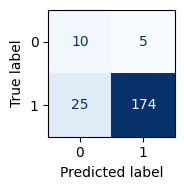

In [105]:
rf_class_model= RandomForestClassifier(
        n_estimators=50,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

rf_class_model.fit(X_train, y_train_rf)
y_pred_rf = rf_class_model.predict(X_test)

print("Random Forest classification report:")
print(classification_report(y_test_rf, y_pred_rf, digits=3))

fig, ax = plt.subplots(figsize=(2,2))
ConfusionMatrixDisplay.from_estimator(
    rf_class_model, X_test, y_test_rf, labels=[0,1], cmap="Blues", ax=ax,colorbar=False
)

plt.tight_layout()
plt.show()

The macro F1 for the class 0 is = 0.4, confirming the model struggles to identify below-speciality. This is expected given the limited training examples for the class '0'.

##  Hyperparameter tuning

We start by choosing the best n_estimators, which defines the number of Decision trees that ake up our Random Forest.

Text(0, 0.5, 'f1_score')

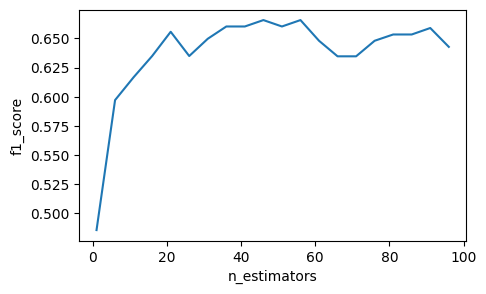

In [107]:

n_values = np.arange(1,101,5)
accuracy_list_train = []
accuracy_list_test = []
f1_list = []

for n_est in n_values:
    rf_model= RandomForestClassifier(
        n_estimators=n_est,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_model.fit(X_train, y_train_rf)
    y_pred_test = rf_model.predict(X_test) #test
    f1_list.append(f1_score(y_test_rf,y_pred_test, average='macro'))

plt.figure(figsize=(5, 3))
plt.plot(n_values,f1_list)
plt.xlabel('n_estimators')
plt.ylabel('f1_score')

n_estimators= 50 gives us the highest f1_score, however by leaving the other hyperparameters at their fixed of default values.

To check every combination, we use GridSearchCV.


In [108]:
param_grid = {
    "n_estimators": [10, 50, 100, 200,300,400],
    "min_samples_split": [ 2, 5, 15, 30,45],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_depth": [None, 2, 3],
}
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid=param_grid,
    scoring="f1_macro",  
    cv=5,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train_rf)

print("Best params:", grid_search.best_params_)
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 30, 'n_estimators': 200}
Best CV f1_macro: 0.6730


              precision    recall  f1-score   support

           0      0.222     0.800     0.348        15
           1      0.981     0.789     0.875       199

    accuracy                          0.790       214
   macro avg      0.602     0.794     0.611       214
weighted avg      0.928     0.790     0.838       214



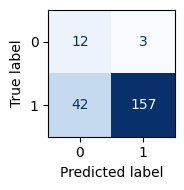

In [109]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
print(classification_report(y_test_rf, y_pred_best, digits=3))

fig, ax = plt.subplots(figsize=(2, 2))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test_rf, labels=[0, 1], cmap="Blues", ax=ax, colorbar=False
)
plt.tight_layout()
plt.show()

# XGBoost Classifier

We test XGBoost as it gives preference to the training examples that did not do well.

In [94]:
n = int(len(X_train)*0.8)
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train_rf[:n], y_train_rf[n:]

xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = RANDOM_STATE,  early_stopping_rounds = 10)
xgb_model.fit(X_train_fit,y_train_fit, eval_set = [(X_train_eval,y_train_eval)])


[0]	validation_0-logloss:0.30130
[1]	validation_0-logloss:0.29534
[2]	validation_0-logloss:0.29225
[3]	validation_0-logloss:0.28868
[4]	validation_0-logloss:0.28618
[5]	validation_0-logloss:0.28167
[6]	validation_0-logloss:0.28091
[7]	validation_0-logloss:0.27917
[8]	validation_0-logloss:0.27579
[9]	validation_0-logloss:0.27392
[10]	validation_0-logloss:0.27159
[11]	validation_0-logloss:0.27124
[12]	validation_0-logloss:0.27051
[13]	validation_0-logloss:0.26988
[14]	validation_0-logloss:0.26817
[15]	validation_0-logloss:0.26657
[16]	validation_0-logloss:0.26601
[17]	validation_0-logloss:0.26485
[18]	validation_0-logloss:0.26438
[19]	validation_0-logloss:0.26468
[20]	validation_0-logloss:0.26497
[21]	validation_0-logloss:0.26481
[22]	validation_0-logloss:0.26420
[23]	validation_0-logloss:0.26387
[24]	validation_0-logloss:0.26451
[25]	validation_0-logloss:0.26453
[26]	validation_0-logloss:0.26428
[27]	validation_0-logloss:0.26425
[28]	validation_0-logloss:0.26451
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,10
,enable_categorical,False
,eval_metric,None


In [95]:
print(xgb_model.best_iteration)
print(classification_report(y_test_rf, xgb_model.predict(X_test), digits=3))


29
              precision    recall  f1-score   support

           0      0.389     0.467     0.424        15
           1      0.959     0.945     0.952       199

    accuracy                          0.911       214
   macro avg      0.674     0.706     0.688       214
weighted avg      0.919     0.911     0.915       214



All models overall strugle with the class 0, however XGBoost gives a higher macro F1 score than Random Forest.